<a href="https://colab.research.google.com/github/chandraharshini/project-1-over-data-cleaning-over-view/blob/main/har_intenship_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning & Visualization Project

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Example: Loading a CSV file
# df = pd.read_csv('your_dataset.csv')

# Placeholder for your data loading code
# For demonstration, let's create a dummy DataFrame
data = {
    'FeatureA': [10, 20, np.nan, 40, 50, 100, 10, 25, 30, 45],
    'FeatureB': ['A', 'B', 'A', 'C', 'B', 'A', 'D', 'C', 'B', 'A'],
    'NumericalValue': [1.1, 2.2, 3.3, 4.4, 5.5, 6.6, 7.7, 8.8, 9.9, 10.0],
    'Date': pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08', '2023-01-09', '2023-01-10'])
}
df = pd.DataFrame(data)


print("Dataset loaded. Displaying the first 5 rows:")
display(df.head())

Dataset loaded. Displaying the first 5 rows:


,FeatureA,FeatureB,NumericalValue,Date
0,10.0,A,1.1,2023-01-01
1,20.0,B,2.2,2023-01-02
2,NaN,A,3.3,2023-01-03
3,40.0,C,4.4,2023-01-04
4,50.0,B,5.5,2023-01-05


## 2. Initial Data Exploration

Before cleaning, let's explore the dataset to understand its basic characteristics, identify missing values, and get a statistical summary.

In [7]:
print("### Dataset Information (Data Types, Non-Null Counts): ###")
df.info()

### Dataset Information (Data Types, Non-Null Counts): ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   FeatureA        9 non-null      float64       
 1   FeatureB        10 non-null     object        
 2   NumericalValue  10 non-null     float64       
 3   Date            10 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 452.0+ bytes


In [8]:
print("\n### Missing Values: ###")
display(df.isnull().sum())


### Missing Values: ###


,0
FeatureA,1
FeatureB,0
NumericalValue,0
Date,0


In [9]:
print("\n### Descriptive Statistics for Numerical Columns: ###")
display(df.describe())


### Descriptive Statistics for Numerical Columns: ###


,FeatureA,NumericalValue,Date
count,9.000000,10.000000,10
mean,36.666667,5.950000,2023-01-05 12:00:00
min,10.000000,1.100000,2023-01-01 00:00:00
25%,20.000000,3.575000,2023-01-03 06:00:00
50%,30.000000,6.050000,2023-01-05 12:00:00
75%,45.000000,8.525000,2023-01-07 18:00:00
max,100.000000,10.000000,2023-01-10 00:00:00
std,27.726341,3.176738,NaN


In [10]:
print("\n### Check for Duplicate Rows: ###")
print(f"Number of duplicate rows: {df.duplicated().sum()}")


### Check for Duplicate Rows: ###
Number of duplicate rows: 0


In [11]:
print("\n### Unique Values and Counts for Categorical Columns: ###")
for column in df.select_dtypes(include='object').columns:
    print(f"\nUnique values in '{column}':")
    print(df[column].value_counts())


### Unique Values and Counts for Categorical Columns: ###

Unique values in 'FeatureB':
FeatureB
A    4
B    3
C    2
D    1
Name: count, dtype: int64


In [12]:
print("Original DataFrame with missing values:")
display(df)

# Fill missing values in 'FeatureA' with its mean
df['FeatureA'] = df['FeatureA'].fillna(df['FeatureA'].mean())

print("\nDataFrame after filling missing values in 'FeatureA':")
display(df)

print("\nMissing values after imputation:")
display(df.isnull().sum())

Original DataFrame with missing values:


,FeatureA,FeatureB,NumericalValue,Date
0,10.0,A,1.1,2023-01-01
1,20.0,B,2.2,2023-01-02
2,NaN,A,3.3,2023-01-03
3,40.0,C,4.4,2023-01-04
4,50.0,B,5.5,2023-01-05
5,100.0,A,6.6,2023-01-06
6,10.0,D,7.7,2023-01-07
7,25.0,C,8.8,2023-01-08
8,30.0,B,9.9,2023-01-09
9,45.0,A,10.0,2023-01-10



DataFrame after filling missing values in 'FeatureA':


,FeatureA,FeatureB,NumericalValue,Date
0,10.000000,A,1.1,2023-01-01
1,20.000000,B,2.2,2023-01-02
2,36.666667,A,3.3,2023-01-03
3,40.000000,C,4.4,2023-01-04
4,50.000000,B,5.5,2023-01-05
5,100.000000,A,6.6,2023-01-06
6,10.000000,D,7.7,2023-01-07
7,25.000000,C,8.8,2023-01-08
8,30.000000,B,9.9,2023-01-09
9,45.000000,A,10.0,2023-01-10



Missing values after imputation:


,0
FeatureA,0
FeatureB,0
NumericalValue,0
Date,0


In [13]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]

if duplicates_removed > 0:
    print(f"Removed {duplicates_removed} duplicate rows.")
else:
    print("No duplicate rows found or removed.")

print("\nDataFrame after removing duplicates (if any):")
display(df.head())

No duplicate rows found or removed.

DataFrame after removing duplicates (if any):


,FeatureA,FeatureB,NumericalValue,Date
0,10.000000,A,1.1,2023-01-01
1,20.000000,B,2.2,2023-01-02
2,36.666667,A,3.3,2023-01-03
3,40.000000,C,4.4,2023-01-04
4,50.000000,B,5.5,2023-01-05


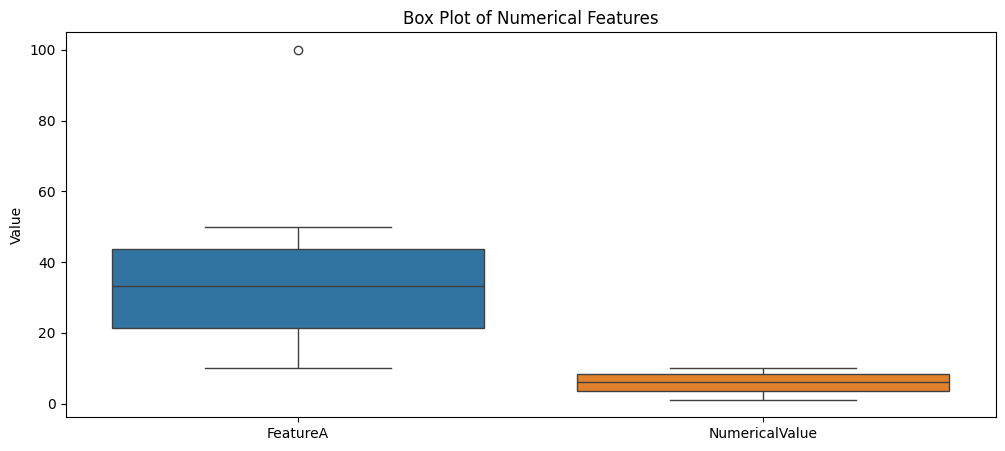

/tmp/ipykernel_2152/365696549.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FeatureB', data=df, palette='viridis')


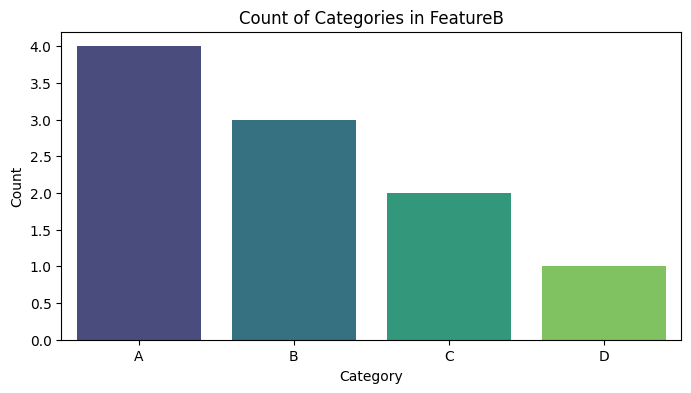

In [14]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[['FeatureA', 'NumericalValue']])
plt.title('Box Plot of Numerical Features')
plt.ylabel('Value')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x='FeatureB', data=df, palette='viridis')
plt.title('Count of Categories in FeatureB')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

### Exploring Relationships and Trends

### Correlation Matrix for Numerical Features: ###


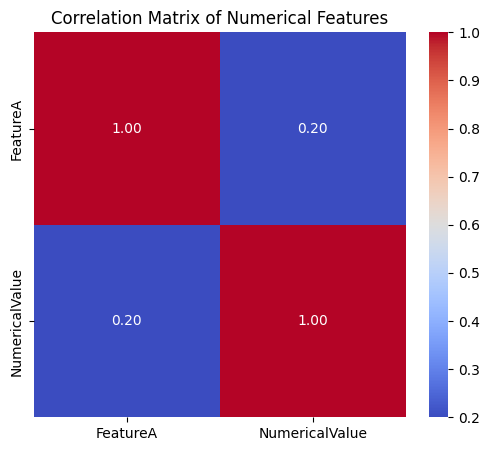

In [15]:
print("### Correlation Matrix for Numerical Features: ###")
correlation_matrix = df[['FeatureA', 'NumericalValue']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Time Series Plot of NumericalValue: ###


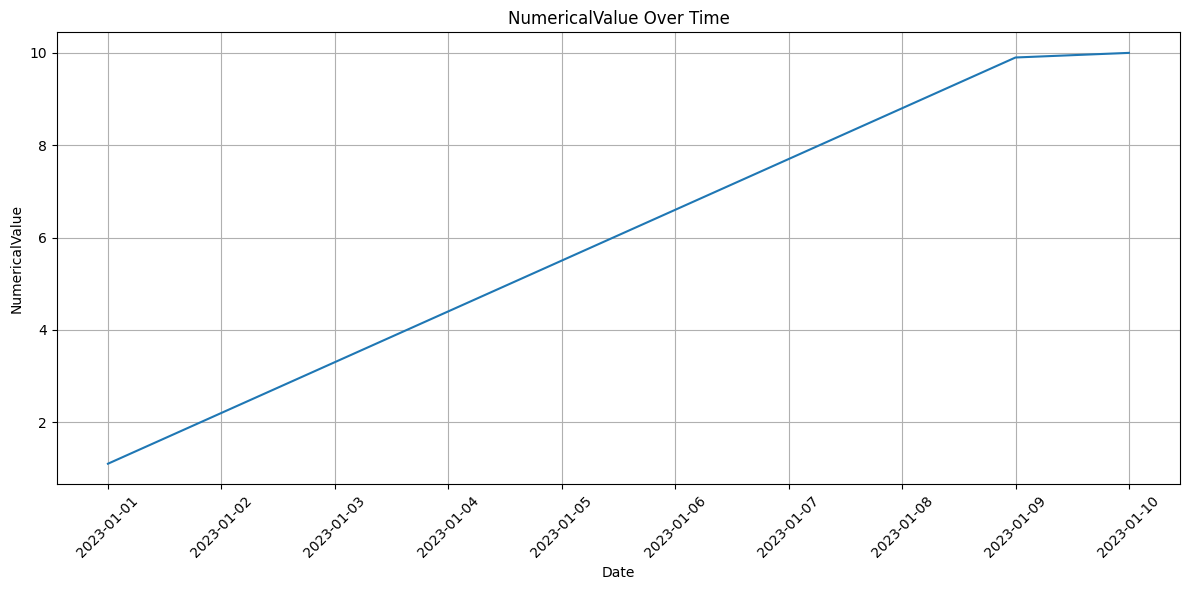

In [16]:
print("### Time Series Plot of NumericalValue: ###")
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='NumericalValue', data=df)
plt.title('NumericalValue Over Time')
plt.xlabel('Date')
plt.ylabel('NumericalValue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bar Plot of NumericalValue by FeatureB: ###


/tmp/ipykernel_2152/2960425492.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FeatureB', y='NumericalValue', data=df, palette='pastel')


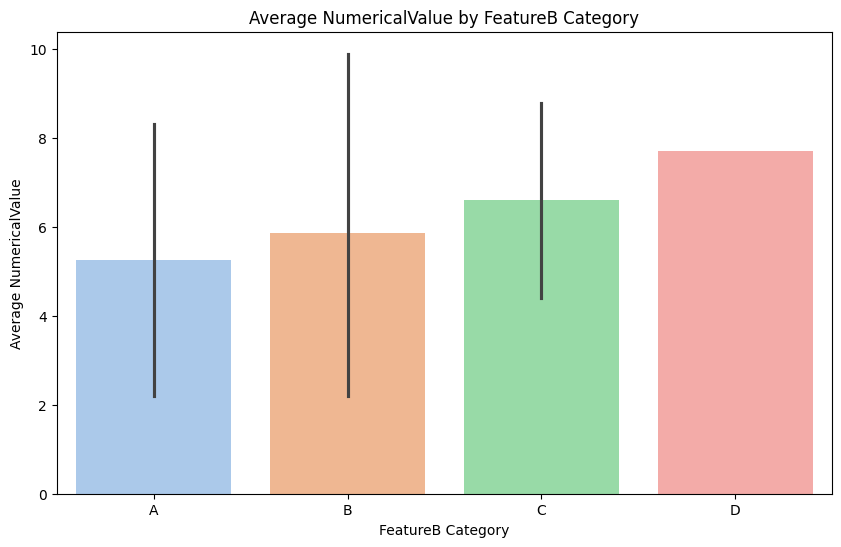

In [17]:
print("### Bar Plot of NumericalValue by FeatureB: ###")
plt.figure(figsize=(10, 6))
sns.barplot(x='FeatureB', y='NumericalValue', data=df, palette='pastel')
plt.title('Average NumericalValue by FeatureB Category')
plt.xlabel('FeatureB Category')
plt.ylabel('Average NumericalValue')
plt.show()

### Box plot to visualize outliers for 'FeatureA' and 'NumericalValue': ###


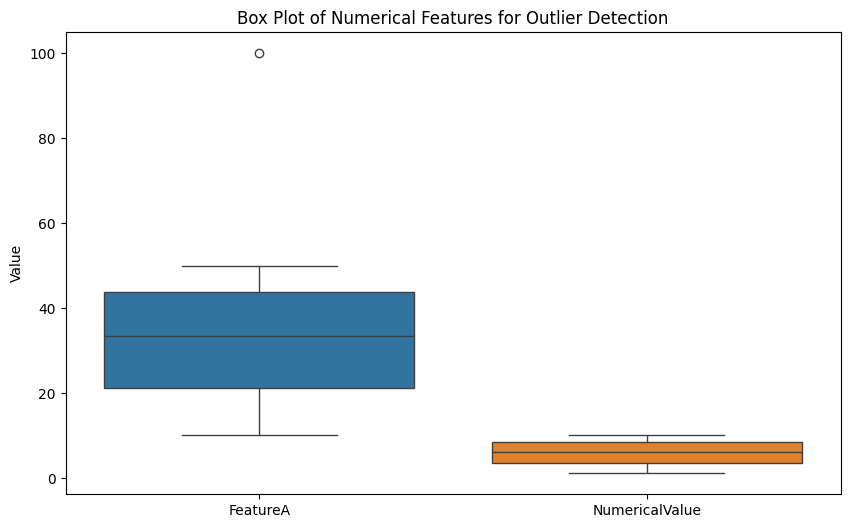

In [18]:
print("### Box plot to visualize outliers for 'FeatureA' and 'NumericalValue': ###")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['FeatureA', 'NumericalValue']])
plt.title('Box Plot of Numerical Features for Outlier Detection')
plt.ylabel('Value')
plt.show()

IQR for FeatureA: 22.5
Lower bound for FeatureA: -12.5
Upper bound for FeatureA: 77.5

DataFrame after capping outliers in 'FeatureA':


,FeatureA,FeatureA_cleaned
0,10.000000,10.000000
1,20.000000,20.000000
2,36.666667,36.666667
3,40.000000,40.000000
4,50.000000,50.000000
5,100.000000,77.500000
6,10.000000,10.000000
7,25.000000,25.000000
8,30.000000,30.000000
9,45.000000,45.000000


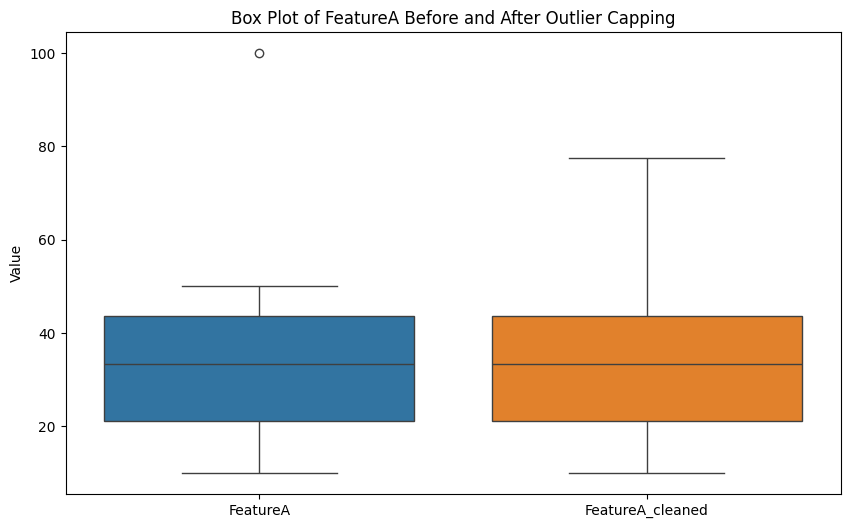

In [19]:
# Calculate IQR for 'FeatureA'
Q1 = df['FeatureA'].quantile(0.25)
Q3 = df['FeatureA'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"IQR for FeatureA: {IQR}")
print(f"Lower bound for FeatureA: {lower_bound}")
print(f"Upper bound for FeatureA: {upper_bound}")

# Identify and cap outliers
df['FeatureA_cleaned'] = df['FeatureA'].copy()
df.loc[df['FeatureA_cleaned'] < lower_bound, 'FeatureA_cleaned'] = lower_bound
df.loc[df['FeatureA_cleaned'] > upper_bound, 'FeatureA_cleaned'] = upper_bound

print("\nDataFrame after capping outliers in 'FeatureA':")
display(df[['FeatureA', 'FeatureA_cleaned']].head(10))

# Visualize 'FeatureA' after outlier capping
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['FeatureA', 'FeatureA_cleaned']])
plt.title('Box Plot of FeatureA Before and After Outlier Capping')
plt.ylabel('Value')
plt.show()